# 01 — Maxwell Dataset Generation for Inverse EM Localization

This notebook generates synthetic multistatic electromagnetic datasets using a compact Maxwell/FDTD forward model.

We generate three supervised datasets of increasing inverse-problem dimension:

1. `data_xy`   : predict tumor center `(x, y)`
2. `data_xyr`  : predict tumor center and radius `(x, y, r)`
3. `data_xyrc` : predict tumor center, radius, and contrast `(x, y, r, c)`

All datasets use the same:
- 2D domain
- antenna geometry
- operating frequency
- background medium
- compact Maxwell forward solver

The goal is to study how inverse prediction degrades as the dimension of the unknown parameter vector increases.

In [1]:
# =========================================================
# Imports
# =========================================================
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# allow notebook to import from project root
sys.path.append(os.path.abspath(".."))

from config import (
    PATHS, Lx, Ly, Nx_fdtd, Ny_fdtd,
    N_ant, ant_x, ant_y,
    eps_r_bg, sigma_bg,
    N_SAMPLES_XY, N_SAMPLES_XYR, N_SAMPLES_XYRC,
    save_npz, savefig
)

from src.maxwell import (
    x_fdtd, y_fdtd, Xfdt, Yfdt,
    build_material_maps,
    build_background_maps,
    simulate_multistatic_measurement,
    complex_matrix_to_tensor,
    generate_dataset_xy,
    generate_dataset_xyr,
    generate_dataset_xyrc
)

In [2]:
# =========================================================
# Quick configuration check
# =========================================================
print("Processed data path :", PATHS["data"])
print("Figures path        :", PATHS["figures"])
print("Intermediate path   :", PATHS["intermediate"])
print()
print("Domain size         :", (Lx, Ly))
print("FDTD grid           :", (Ny_fdtd, Nx_fdtd))
print("Number of antennas  :", N_ant)
print()
print("Planned sample counts:")
print("  XY   :", N_SAMPLES_XY)
print("  XYR  :", N_SAMPLES_XYR)
print("  XYRC :", N_SAMPLES_XYRC)

Processed data path : /Users/suvo/Projects/em-inverse/data/processed
Figures path        : /Users/suvo/Projects/em-inverse/outputs/figures
Intermediate path   : /Users/suvo/Projects/em-inverse/outputs/intermediate

Domain size         : (0.2, 0.2)
FDTD grid           : (100, 100)
Number of antennas  : 16

Planned sample counts:
  XY   : 300
  XYR  : 400
  XYRC : 500


In [3]:
# =========================================================
# Sanity-check one sample geometry and one measurement matrix
# =========================================================
x0, y0, r0, c0, sigma0 = 0.03, -0.02, 0.01, 45.0, 4.0

eps_r_map0, sigma_map0, tumor_mask0 = build_material_maps(x0, y0, r0, c0, sigma0)
M0 = simulate_multistatic_measurement(x0, y0, r0, c0, sigma0)
X0 = complex_matrix_to_tensor(M0)

print("One measurement matrix shape :", M0.shape)
print("One CNN input tensor shape   :", X0.shape)
print("Max |M0|                     :", np.abs(M0).max())

One measurement matrix shape : (16, 16)
One CNN input tensor shape   : (16, 16, 2)
Max |M0|                     : 0.02879745995760363


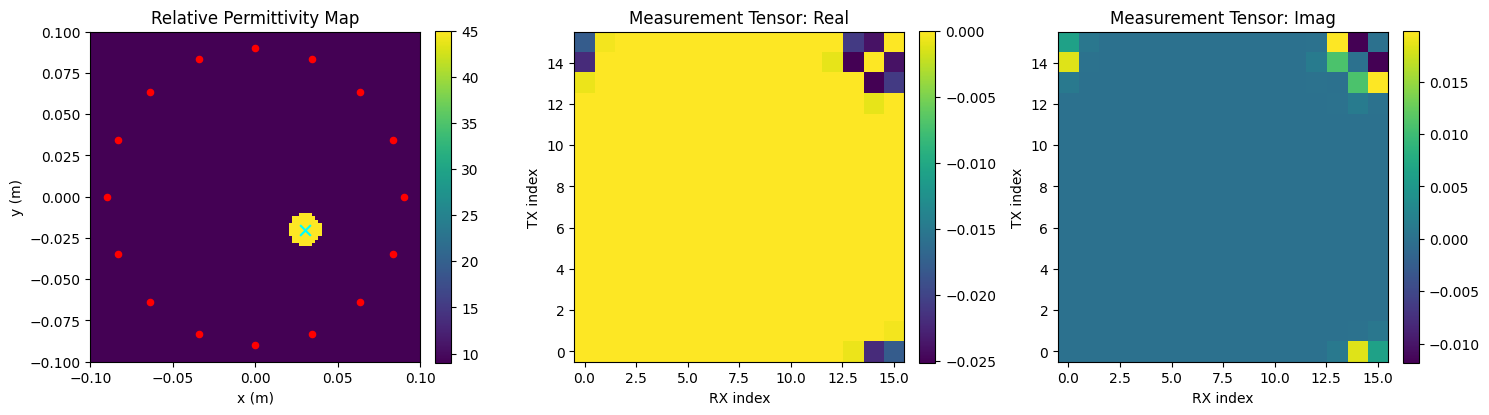

In [4]:
# =========================================================
# Plot sanity-check geometry and measurement tensor
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# geometry
im0 = axes[0].imshow(
    eps_r_map0,
    extent=[x_fdtd.min(), x_fdtd.max(), y_fdtd.min(), y_fdtd.max()],
    origin="lower",
    aspect="equal"
)
axes[0].scatter(ant_x, ant_y, c="red", s=20)
axes[0].scatter(x0, y0, c="cyan", s=60, marker="x")
axes[0].set_title("Relative Permittivity Map")
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# real part
im1 = axes[1].imshow(X0[..., 0], origin="lower", aspect="equal")
axes[1].set_title("Measurement Tensor: Real")
axes[1].set_xlabel("RX index")
axes[1].set_ylabel("TX index")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# imag part
im2 = axes[2].imshow(X0[..., 1], origin="lower", aspect="equal")
axes[2].set_title("Measurement Tensor: Imag")
axes[2].set_xlabel("RX index")
axes[2].set_ylabel("TX index")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Generate and save `data_xy`

In this dataset, only tumor location varies.  
The target is `(x, y)`.

In [5]:
# =========================================================
# Generate data_xy
# =========================================================
rng = np.random.default_rng(42)

X_xy, y_xy = generate_dataset_xy(N_SAMPLES_XY, rng=rng)

print("X_xy shape:", X_xy.shape)
print("y_xy shape:", y_xy.shape)

[xy] generated 1/300
[xy] generated 10/300
[xy] generated 20/300
[xy] generated 30/300
[xy] generated 40/300
[xy] generated 50/300
[xy] generated 60/300
[xy] generated 70/300
[xy] generated 80/300
[xy] generated 90/300
[xy] generated 100/300
[xy] generated 110/300
[xy] generated 120/300
[xy] generated 130/300
[xy] generated 140/300
[xy] generated 150/300
[xy] generated 160/300
[xy] generated 170/300
[xy] generated 180/300
[xy] generated 190/300
[xy] generated 200/300
[xy] generated 210/300
[xy] generated 220/300
[xy] generated 230/300
[xy] generated 240/300
[xy] generated 250/300
[xy] generated 260/300
[xy] generated 270/300
[xy] generated 280/300
[xy] generated 290/300
[xy] generated 300/300
X_xy shape: (300, 16, 16, 2)
y_xy shape: (300, 2)


In [6]:
# =========================================================
# Save data_xy
# =========================================================
save_npz("data_xy", X=X_xy, y=y_xy)

Saved: /Users/suvo/Projects/em-inverse/data/processed/data_xy.npz


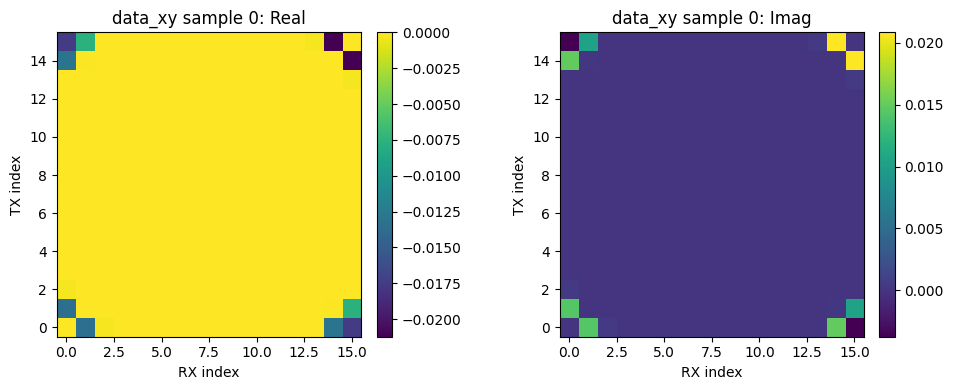

Target [x, y] = [ 0.03287473 -0.00733459]


In [7]:
# =========================================================
# Quick inspect one random XY sample
# =========================================================
idx = 0

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(X_xy[idx, ..., 0], origin="lower", aspect="equal")
axes[0].set_title(f"data_xy sample {idx}: Real")
axes[0].set_xlabel("RX index")
axes[0].set_ylabel("TX index")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(X_xy[idx, ..., 1], origin="lower", aspect="equal")
axes[1].set_title(f"data_xy sample {idx}: Imag")
axes[1].set_xlabel("RX index")
axes[1].set_ylabel("TX index")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("Target [x, y] =", y_xy[idx])

## Generate and save `data_xyr`

In this dataset, tumor location and radius vary.  
The target is `(x, y, r)`.

In [8]:
# =========================================================
# Generate data_xyr
# =========================================================
rng = np.random.default_rng(43)

X_xyr, y_xyr = generate_dataset_xyr(N_SAMPLES_XYR, rng=rng)

print("X_xyr shape:", X_xyr.shape)
print("y_xyr shape:", y_xyr.shape)

[xyr] generated 1/400
[xyr] generated 10/400
[xyr] generated 20/400
[xyr] generated 30/400
[xyr] generated 40/400
[xyr] generated 50/400
[xyr] generated 60/400
[xyr] generated 70/400
[xyr] generated 80/400
[xyr] generated 90/400
[xyr] generated 100/400
[xyr] generated 110/400
[xyr] generated 120/400
[xyr] generated 130/400
[xyr] generated 140/400
[xyr] generated 150/400
[xyr] generated 160/400
[xyr] generated 170/400
[xyr] generated 180/400
[xyr] generated 190/400
[xyr] generated 200/400
[xyr] generated 210/400
[xyr] generated 220/400
[xyr] generated 230/400
[xyr] generated 240/400
[xyr] generated 250/400
[xyr] generated 260/400
[xyr] generated 270/400
[xyr] generated 280/400
[xyr] generated 290/400
[xyr] generated 300/400
[xyr] generated 310/400
[xyr] generated 320/400
[xyr] generated 330/400
[xyr] generated 340/400
[xyr] generated 350/400
[xyr] generated 360/400
[xyr] generated 370/400
[xyr] generated 380/400
[xyr] generated 390/400
[xyr] generated 400/400
X_xyr shape: (400, 16, 16, 

In [9]:
# =========================================================
# Save data_xyr
# =========================================================
save_npz("data_xyr", X=X_xyr, y=y_xyr)

Saved: /Users/suvo/Projects/em-inverse/data/processed/data_xyr.npz


## Generate and save `data_xyrc`

In this dataset, tumor location, radius, and contrast vary.  
The target is `(x, y, r, c)`.

In [10]:
# =========================================================
# Generate data_xyrc
# =========================================================
rng = np.random.default_rng(44)

X_xyrc, y_xyrc = generate_dataset_xyrc(N_SAMPLES_XYRC, rng=rng)

print("X_xyrc shape:", X_xyrc.shape)
print("y_xyrc shape:", y_xyrc.shape)

[xyrc] generated 1/500
[xyrc] generated 10/500
[xyrc] generated 20/500
[xyrc] generated 30/500
[xyrc] generated 40/500
[xyrc] generated 50/500
[xyrc] generated 60/500
[xyrc] generated 70/500
[xyrc] generated 80/500
[xyrc] generated 90/500
[xyrc] generated 100/500
[xyrc] generated 110/500
[xyrc] generated 120/500
[xyrc] generated 130/500
[xyrc] generated 140/500
[xyrc] generated 150/500
[xyrc] generated 160/500
[xyrc] generated 170/500
[xyrc] generated 180/500
[xyrc] generated 190/500
[xyrc] generated 200/500
[xyrc] generated 210/500
[xyrc] generated 220/500
[xyrc] generated 230/500
[xyrc] generated 240/500
[xyrc] generated 250/500
[xyrc] generated 260/500
[xyrc] generated 270/500
[xyrc] generated 280/500
[xyrc] generated 290/500
[xyrc] generated 300/500
[xyrc] generated 310/500
[xyrc] generated 320/500
[xyrc] generated 330/500
[xyrc] generated 340/500
[xyrc] generated 350/500
[xyrc] generated 360/500
[xyrc] generated 370/500
[xyrc] generated 380/500
[xyrc] generated 390/500
[xyrc] gene

In [11]:
# =========================================================
# Save data_xyrc
# =========================================================
save_npz("data_xyrc", X=X_xyrc, y=y_xyrc)

Saved: /Users/suvo/Projects/em-inverse/data/processed/data_xyrc.npz
